In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Payoff refers to profit in this context
def CalculateLongCallPayoff(stockPrice, strikePrice, premium):
    return np.where(stockPrice < strikePrice, -premium, stockPrice - strikePrice - premium)

def CalculateLongPutPayoff(stockPrice, strikePrice, premium):
    return np.where(stockPrice < strikePrice, strikePrice - stockPrice - premium, -premium)

def CalculateShortCallPayoff(stockPrice, strikePrice, premium):
    return np.where(stockPrice < strikePrice, premium, premium + strikePrice - stockPrice)

def CalculateShortPutPayoff(stockPrice, strikePrice, premium):
    return np.where(stockPrice < strikePrice, stockPrice + premium - strikePrice, premium)

In [3]:
payoffs = pd.DataFrame(columns=["Stock Price", "Long Call", "Long Put", "Short Call", "Short Put"])

stockPrice = np.arange(1, 101)
payoffs["Stock Price"] = stockPrice
strikePrice = 50
premium = 10

payoffs["Long Call"]  = CalculateLongCallPayoff(payoffs["Stock Price"].values, strikePrice, premium)
payoffs["Long Put"]   = CalculateLongPutPayoff(payoffs["Stock Price"].values, strikePrice, premium)
payoffs["Short Call"] = CalculateShortCallPayoff(payoffs["Stock Price"].values, strikePrice, premium)
payoffs["Short Put"]  = CalculateShortPutPayoff(payoffs["Stock Price"].values, strikePrice, premium)

payoffs

,Stock Price,Long Call,Long Put,Short Call,Short Put
0,1,-10,39,10,-39
1,2,-10,38,10,-38
2,3,-10,37,10,-37
3,4,-10,36,10,-36
4,5,-10,35,10,-35
...,...,...,...,...,...
95,96,36,-10,-36,10
96,97,37,-10,-37,10
97,98,38,-10,-38,10
98,99,39,-10,-39,10


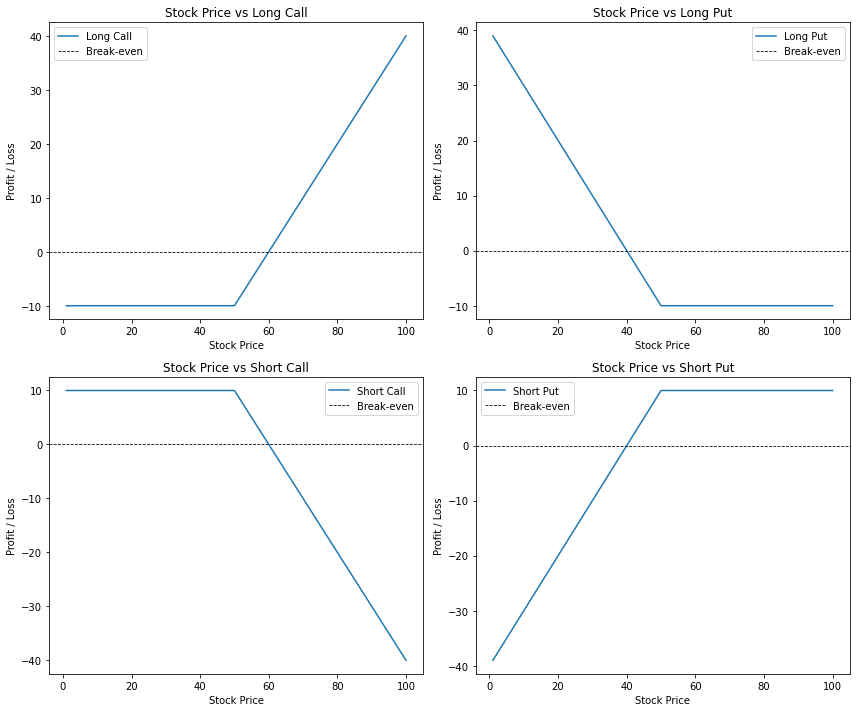

In [4]:
# plotting subgraphs
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()
y_columns = payoffs.columns[1:5]
x_column = payoffs.columns[0]

for i, y_col in enumerate(y_columns):
    ax = axes[i]
    ax.plot(payoffs[x_column], payoffs[y_col], label=y_col)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8, label="Break-even")
    ax.set_title(f"{x_column} vs {y_col}")
    ax.set_xlabel(x_column)
    ax.set_ylabel("Profit / Loss")
    ax.legend()

plt.tight_layout()
plt.show()

In [5]:
## covered call: long stock + short call, initial cost of stock being 40
initialCostOfStock = 40
payoffs["Covered Call"] = (CalculateShortCallPayoff(payoffs["Stock Price"].values, strikePrice, premium)
                           + payoffs["Stock Price"] - initialCostOfStock)
payoffs["Covered Call"]

0    -29
1    -28
2    -27
3    -26
4    -25
      ..
95    20
96    20
97    20
98    20
99    20
Name: Covered Call, Length: 100, dtype: int32

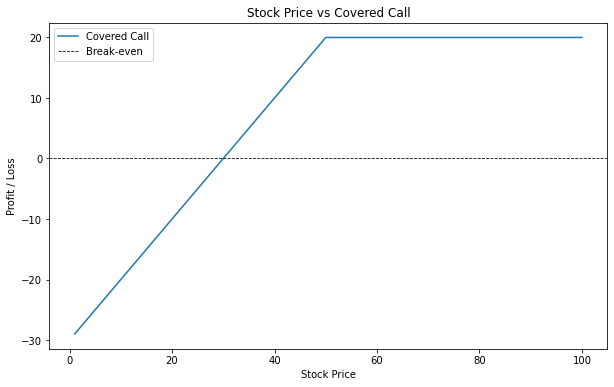

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(payoffs["Stock Price"], payoffs["Covered Call"], label="Covered Call")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8, label="Break-even")
plt.title("Stock Price vs Covered Call")
plt.xlabel("Stock Price")
plt.ylabel("Profit / Loss")
plt.legend()
plt.show()